In [35]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Colab Notebooks/Personal Projects/Project_2_sales_analysis/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
orders = pd.read_csv(folder_path+"orders_clean.csv")
customers = pd.read_csv(folder_path+"customers_clean.csv")
products = pd.read_csv(folder_path+"products_clean.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["customer_since"] = pd.to_datetime(customers["customer_since"])


orders.shape, customers.shape, products.shape

((30000, 17), (2500, 6), (72, 6))

# Sales & Business Performance Analysis

## Executive Overview

This analysis evaluates sales performance, profitability, customer value, discounting, and order outcomes for a fictional mid-sized e-commerce business covering 2023–2025.

### Key findings

- Annual revenue remained broadly stable at approximately ₹365–370M, with profit margins consistently around 24.6%.
- Revenue shows moderate recurring seasonality, with February tending to be weaker and September and December relatively stronger.
- Office Supplies has substantially lower profitability than the other categories, with a 5.8% profit margin.
- Six Office Supplies products are loss-making, four of which belong to the Writing subcategory. The largest losses are concentrated in these Writing products.
- Higher discount levels are associated with lower profit margins. Margin declines from 31.5% at 0% discount to 9.0% at 25%, although this analysis does not establish causality.
- The top 10% of customers by cumulative profit contribute 21.2% of total customer profit, indicating that profit is not heavily concentrated among a small group of customers.
- Home Appliances has the highest return rate at 7.7%, although differences across categories are moderate.

## 1. Revenue & Order Trends

The first objective is to understand whether the business is growing, stable, or declining over the three-year period. I examine annual order volume, revenue, average revenue per order, and profit.

### Annual Performance

In [37]:
annual_summary = orders.groupby(
    orders["order_date"].dt.year
).agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum")
)

annual_summary["total_orders_k"] = (
    annual_summary["total_orders"] / 1_000
)

annual_summary["total_revenue_m"] = (
    annual_summary["total_revenue"] / 1_000_000
)

annual_summary["total_profit_m"] = (
    annual_summary["total_profit"] / 1_000_000
)

annual_summary["revenue_per_order"] = (
    annual_summary["total_revenue"] / annual_summary["total_orders"]
)

annual_summary["profit_margin"] = (
    annual_summary["total_profit"]
    / annual_summary["total_revenue"]
    * 100
)

annual_summary[
    ["total_orders_k", "total_revenue_m", "revenue_per_order", "total_profit_m", "profit_margin"]
]

,total_orders_k,total_revenue_m,revenue_per_order,total_profit_m,profit_margin
order_date,,,,,
2023,9.937,367.360658,36968.970302,90.470827,24.627250
2024,9.951,364.754652,36655.075034,89.613265,24.568094
2025,10.112,369.900902,36580.389799,91.156544,24.643504


### Annual Revenue Trend

Annual revenue remained broadly stable across the three-year period, with a small dip in 2024 followed by a recovery in 2025.

Text(0, 0.5, 'Revenue (₹M)')

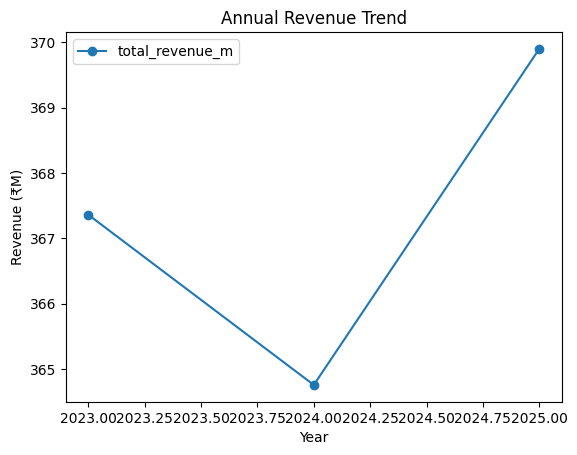

In [38]:
annual_summary["year"] = annual_summary.index

annual_summary.plot(
    x="year",
    y="total_revenue_m",
    kind="line",
    marker="o",
    title="Annual Revenue Trend"
)

plt.xlabel("Year")
plt.ylabel("Revenue (₹M)")

**Interpretation:** Revenue remained broadly stable over the three-year period. It declined slightly in 2024 before recovering in 2025. Overall, there is no strong evidence of sustained revenue growth or deterioration during the period.

### Order Volume and Revenue per Order

In [39]:
annual_summary[
    ["total_orders_k", "revenue_per_order"]
]

,total_orders_k,revenue_per_order
order_date,,
2023,9.937,36968.970302
2024,9.951,36655.075034
2025,10.112,36580.389799


**Interpretation:** Order volume increased modestly from 9.94K in 2023 to 10.11K in 2025, while revenue per order declined slightly from approximately ₹36,969 to ₹36,580. The increase in order volume therefore largely offset the decline in order value, resulting in broadly stable overall revenue.

### Annual Profitability

In [40]:
annual_summary[
    ["total_profit_m", "profit_margin"]
]

,total_profit_m,profit_margin
order_date,,
2023,90.470827,24.627250
2024,89.613265,24.568094
2025,91.156544,24.643504


**Interpretation:** Profit remained stable at approximately ₹90–91M per year, while profit margin stayed close to 24.6% throughout the period. Despite small year-to-year fluctuations, there is no evidence of a meaningful change in overall profitability.

### Monthly Revenue Pattern

Monthly revenue is examined to identify recurring periods of stronger or weaker sales activity across the three-year period.

In [41]:
orders["month"] = orders["order_date"].dt.month

seasonality = orders.groupby(
    ["month", orders["order_date"].dt.year]
)["revenue"].sum().unstack()

seasonality = seasonality / 1_000_000

seasonality

order_date,2023,2024,2025
month,,,
1,33.179284,31.576355,32.673206
2,26.669621,28.424565,26.062098
3,31.120136,32.246294,31.550885
4,32.948859,30.422441,29.379364
5,30.360335,32.419320,29.144418
6,29.981015,29.982287,30.419169
7,28.019130,30.256036,33.824965
8,31.119756,29.900979,30.043857
9,32.903921,31.971327,31.655622


### Revenue Seasonality Across Years

Text(0, 0.5, 'Revenue (₹M)')

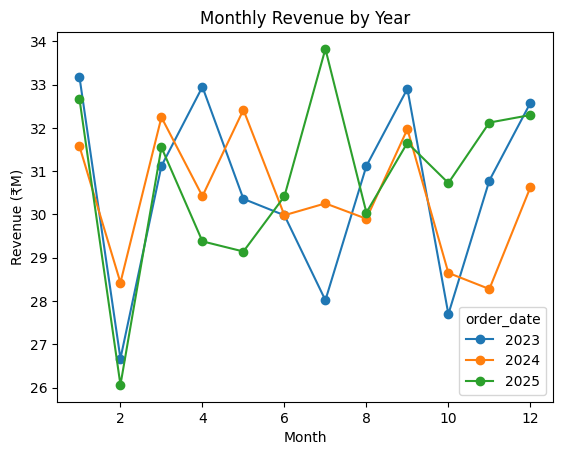

In [42]:
seasonality.plot(
    kind="line",
    marker="o",
    title="Monthly Revenue by Year"
)

plt.xlabel("Month")
plt.ylabel("Revenue (₹M)")

**Interpretation:** Monthly revenue shows some recurring seasonal patterns, although the overall effect is moderate rather than strong. February is consistently one of the weaker months, while September and December tend to be relatively strong across the three-year period. Other monthly movements vary considerably by year.

## 2. Profitability by Category

The next objective is to identify which product categories contribute most to revenue and profit, and whether differences in profitability are driven by margins, product costs, or fulfillment costs.

### Category-Level Profitability

In [43]:
category_summary = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
).groupby("category").agg(
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    total_shipping=("shipping_cost", "sum")
)

category_summary["profit_margin"] = (
    category_summary["total_profit"]
    / category_summary["total_revenue"]
    * 100
)

category_summary["revenue_m"] = (
    category_summary["total_revenue"] / 1_000_000
)

category_summary["profit_m"] = (
    category_summary["total_profit"] / 1_000_000
)

category_summary["shipping_m"] = (
    category_summary["total_shipping"] / 1_000_000
)

category_summary[
    ["revenue_m", "profit_m", "profit_margin", "shipping_m"]
]

,revenue_m,profit_m,profit_margin,shipping_m
category,,,,
Electronics,659.723109,167.539948,25.395495,5.894327
Furniture,236.870142,58.102933,24.529446,5.945851
Home Appliances,174.142983,43.790134,25.146080,5.849230
Office Supplies,31.279977,1.807620,5.778842,5.752571


Text(0, 0.5, 'Profit Margin (%)')

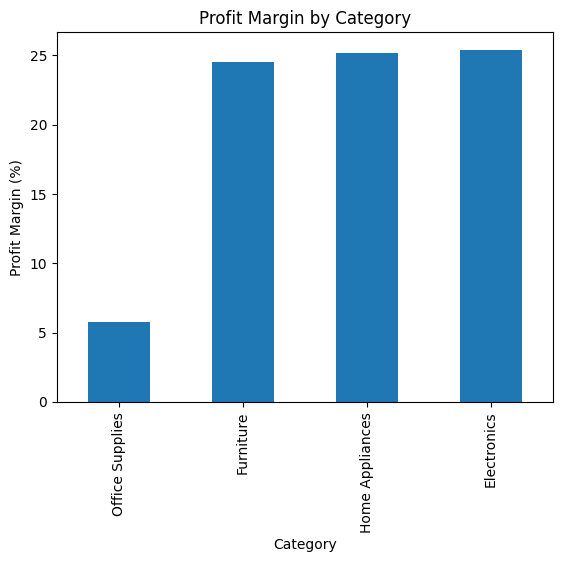

In [44]:
category_summary["profit_margin"].sort_values().plot(
    kind="bar",
    title="Profit Margin by Category"
)

plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

**Interpretation:** Office Supplies has a substantially lower profit margin (5.8%) than the other categories, which range from 24.5% to 25.4%. The result indicates materially weaker profitability within the category and warrants further investigation at the subcategory and product levels.

### Office Supplies: Subcategory Profitability

In [45]:
office_supplies = orders.merge(
    products[["product_id", "subcategory"]],
    on="product_id",
    how="left"
)

office_supplies = office_supplies[
    office_supplies["subcategory"].isin(
        ["Writing", "Paper", "Stationery"]
    )
]

subcategory_summary = office_supplies.groupby(
    "subcategory"
).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    shipping_cost=("shipping_cost", "sum")
)

subcategory_summary["profit_margin"] = (
    subcategory_summary["profit"]
    / subcategory_summary["revenue"]
    * 100
)

subcategory_summary["revenue_m"] = (
    subcategory_summary["revenue"] / 1_000_000
)

subcategory_summary["profit_m"] = (
    subcategory_summary["profit"] / 1_000_000
)

subcategory_summary["shipping_m"] = (
    subcategory_summary["shipping_cost"] / 1_000_000
)

subcategory_summary[
    ["revenue_m", "profit_m", "profit_margin", "shipping_m"]
]

,revenue_m,profit_m,profit_margin,shipping_m
subcategory,,,,
Paper,11.120209,0.920848,8.280847,2.030802
Stationery,12.636192,1.240433,9.816509,1.884670
Writing,7.523576,-0.353660,-4.700693,1.837099


**Interpretation:** Profitability is weak across all three Office Supplies subcategories, with Writing being the only loss-making subcategory at -4.7% margin. Paper and Stationery remain profitable but at substantially lower margins than the other product categories. The results suggest that Office Supplies has structurally weaker economics, with Writing requiring particular attention.

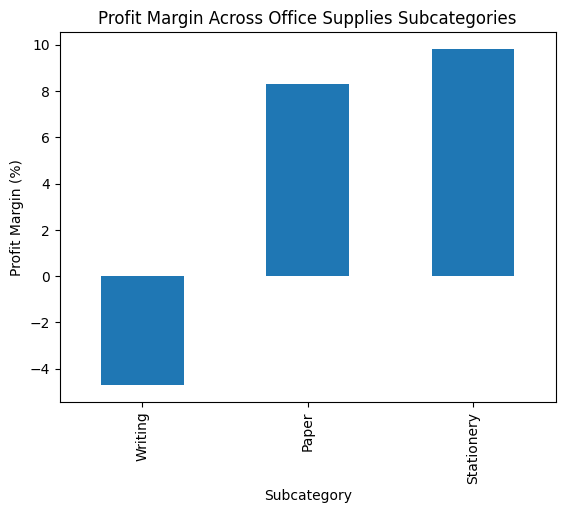

In [46]:
subcategory_summary["profit_margin"].sort_values().plot(
    kind="bar",
    title="Profit Margin Across Office Supplies Subcategories"
)

plt.xlabel("Subcategory")
plt.ylabel("Profit Margin (%)")
plt.show()

**Key takeaway:** Office Supplies is the only category with materially weak profitability. Within the category, Writing is loss-making, while Paper and Stationery generate low but positive margins. The profitability issue is therefore concentrated within a small set of products rather than being representative of the broader business.

### Product-Level Profitability Within Office Supplies

To identify whether the weak profitability is concentrated in specific products, the analysis is further drilled down from subcategory to individual product.

In [47]:
office_product_summary = office_supplies.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
).groupby(
    ["product_id", "product_name"]
).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    shipping_cost=("shipping_cost", "sum")
)

office_product_summary["profit_margin"] = (
    office_product_summary["profit"]
    / office_product_summary["revenue"]
    * 100
)

office_product_summary["revenue_m"] = (
    office_product_summary["revenue"] / 1_000_000
)

office_product_summary["profit_m"] = (
    office_product_summary["profit"] / 1_000_000
)

office_product_summary.sort_values("profit_margin", ascending=True)

,,revenue,profit,shipping_cost,profit_margin,revenue_m,profit_m
product_id,product_name,,,,,,
P0070,Writing Product 4,268049.04,-209314.712623,273992.232623,-78.088216,0.268049,-0.209315
P0069,Writing Product 3,602677.87,-261825.206240,343164.076240,-43.443640,0.602678,-0.261825
P0072,Writing Product 6,600895.75,-196744.555693,347811.805693,-32.741878,0.600896,-0.196745
P0068,Writing Product 2,571745.23,-105843.271243,284860.151243,-18.512314,0.571745,-0.105843
P0066,Paper Product 6,1113515.03,-64425.959391,344504.789391,-5.785819,1.113515,-0.064426
P0058,Stationery Product 4,1522032.31,-74437.131607,349119.751607,-4.890641,1.522032,-0.074437
P0067,Writing Product 1,2342806.05,29525.158988,285568.971012,1.260248,2.342806,0.029525
P0063,Paper Product 3,2710989.78,59634.311585,298021.468415,2.199725,2.710990,0.059634
P0061,Paper Product 1,1644005.79,57726.671694,360142.908306,3.511342,1.644006,0.057727


In [48]:
loss_making_products = office_product_summary[
    office_product_summary["profit"] < 0
].sort_values("profit")

loss_making_products[
    ["revenue_m", "profit_m", "profit_margin"]
]

,,revenue_m,profit_m,profit_margin
product_id,product_name,,,
P0069,Writing Product 3,0.602678,-0.261825,-43.443640
P0070,Writing Product 4,0.268049,-0.209315,-78.088216
P0072,Writing Product 6,0.600896,-0.196745,-32.741878
P0068,Writing Product 2,0.571745,-0.105843,-18.512314
P0058,Stationery Product 4,1.522032,-0.074437,-4.890641
P0066,Paper Product 6,1.113515,-0.064426,-5.785819


**Key takeaway:** Office Supplies contains six loss-making products, four of which belong to Writing. The largest individual losses are concentrated in Writing products, reinforcing the need to review pricing, bundling, or fulfillment economics for low-value products.

## 3. Customer Value

This section evaluates customer-level order frequency, revenue, and profit to understand customer value and whether profitability is concentrated among a small group of customers.

### Customer-Level Economics

In [49]:
customer_summary = orders.groupby("customer_id").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum")
)

customer_summary = customer_summary.merge(
    customers[["customer_id", "customer_segment"]],
    on="customer_id",
    how="left"
)

customer_summary.describe()

,total_orders,total_revenue,total_profit
count,2500.000000,2.500000e+03,2500.000000
mean,12.000000,4.408065e+05,108496.254039
std,3.443362,2.129493e+05,59269.346346
min,2.000000,7.773930e+03,216.870442
25%,10.000000,2.918798e+05,68072.979261
50%,12.000000,4.095007e+05,99210.976719
75%,14.000000,5.615643e+05,139926.423058
max,25.000000,2.759154e+06,841328.622363


In [50]:
customer_summary["profit_margin"] = (
    customer_summary["total_profit"]
    / customer_summary["total_revenue"]
    * 100
)

customer_summary.describe()

,total_orders,total_revenue,total_profit,profit_margin
count,2500.000000,2.500000e+03,2500.000000,2500.000000
mean,12.000000,4.408065e+05,108496.254039,24.175860
std,3.443362,2.129493e+05,59269.346346,4.238405
min,2.000000,7.773930e+03,216.870442,0.550060
25%,10.000000,2.918798e+05,68072.979261,21.575717
50%,12.000000,4.095007e+05,99210.976719,24.368626
75%,14.000000,5.615643e+05,139926.423058,26.795765
max,25.000000,2.759154e+06,841328.622363,37.118282


**Interpretation:** Customers generate a median of approximately ₹409.5K in revenue and ₹99.2K in profit, with a median profit margin of 24.4%. Customer-level margins are relatively consistent for most customers, although a small number of customers have substantially lower or higher margins.

### Customer Profit Concentration

In [51]:
# How much of the company's profit comes from its highest-value customers?

customer_summary["profit_rank"] = customer_summary["total_profit"].rank(
    ascending=False,
    method="first"
)

top_10_pct = customer_summary[
    customer_summary["profit_rank"] <= len(customer_summary) * 0.10
]

top_10_pct_profit_share = (
    top_10_pct["total_profit"].sum()
    / customer_summary["total_profit"].sum()
    * 100
)

top_10_pct_profit_share

np.float64(21.214224854714743)

**Interpretation:** The top 10% of customers by cumulative profit contribute 21.2% of total customer profit. This indicates moderate customer concentration rather than heavy dependence on a small group of high-value customers.

### Customer Segment Economics

In [52]:
# Which customer segment contributes the most customer value?

segment_summary = customer_summary.groupby(
    "customer_segment"
).agg(
    customers=("customer_id", "nunique"),
    total_revenue=("total_revenue", "sum"),
    total_profit=("total_profit", "sum")
)

segment_summary["revenue_per_customer"] = (
    segment_summary["total_revenue"]
    / segment_summary["customers"]
)

segment_summary["profit_per_customer"] = (
    segment_summary["total_profit"]
    / segment_summary["customers"]
)

segment_summary["profit_margin"] = (
    segment_summary["total_profit"]
    / segment_summary["total_revenue"]
    * 100
)

segment_summary

,customers,total_revenue,total_profit,revenue_per_customer,profit_per_customer,profit_margin
customer_segment,,,,,,
Consumer,1486,6.739076e+08,1.662759e+08,453504.429462,111894.974473,24.673403
Enterprise,245,1.033889e+08,2.518131e+07,421995.552531,102780.851235,24.355909
Small Business,769,3.247197e+08,7.978339e+07,422262.312939,103749.537682,24.569926


**Interpretation:** Consumer customers generate slightly higher revenue and profit per customer than Small Business and Enterprise customers. However, profit margins are very similar across all three segments, ranging from 24.4% to 24.7%. This suggests that segment differences in total revenue and profit are driven primarily by the size of each customer group rather than materially different profitability.

## 4. Discounting & Profitability

The next objective is to examine how different discount levels are associated with revenue and profitability. This helps assess whether higher discounts are generating sufficient sales value to offset their impact on profit margins.

### Profitability by Discount Level

In [53]:
discount_summary = orders.groupby("discount_pct").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum")
)

discount_summary["revenue_m"] = (
    discount_summary["total_revenue"] / 1_000_000
)

discount_summary["profit_m"] = (
    discount_summary["total_profit"] / 1_000_000
)

discount_summary["profit_margin"] = (
    discount_summary["total_profit"]
    / discount_summary["total_revenue"]
    * 100
)

discount_summary

,total_orders,total_revenue,total_profit,revenue_m,profit_m,profit_margin
discount_pct,,,,,,
0.00,6086,2.451280e+08,7.732102e+07,245.128006,77.321019,31.543119
0.05,7529,2.848295e+08,7.895734e+07,284.829473,78.957344,27.720918
0.10,7489,2.783868e+08,6.647237e+07,278.386797,66.472366,23.877701
0.15,4422,1.508509e+08,2.966317e+07,150.850889,29.663172,19.663903
0.20,3035,1.009234e+08,1.506887e+07,100.923423,15.068867,14.930991
0.25,1439,4.189762e+07,3.757867e+06,41.897625,3.757867,8.969164


**Interpretation:** Profit margin declines consistently as discount levels increase, falling from 31.5% with no discount to 9.0% at a 25% discount. While higher discounts may support sales volume, the analysis shows a clear association between deeper discounting and lower profitability.

**Business implication:** Discounting should be used selectively, with deeper discounts evaluated against the incremental sales value they generate rather than applied broadly.

### Revenue and Profit per Order

In [54]:
discount_summary["revenue_per_order"] = (
    discount_summary["total_revenue"]
    / discount_summary["total_orders"]
)

discount_summary["profit_per_order"] = (
    discount_summary["total_profit"]
    / discount_summary["total_orders"]
)

discount_summary[
    ["revenue_per_order", "profit_per_order"]
]/1000

,revenue_per_order,profit_per_order
discount_pct,,
0.00,40.277359,12.704735
0.05,37.830983,10.487096
0.10,37.172760,8.876000
0.15,34.113724,6.708090
0.20,33.253187,4.965030
0.25,29.115792,2.611443


**Interpretation:** Higher discount levels are associated with lower revenue per order, declining from approximately ₹40.3K at 0% discount to ₹29.1K at 25%. Profit per order declines more sharply, from ₹12.7K to ₹2.6K. This suggests that deeper discounts are associated with both lower order value and substantially lower profit generated per order.

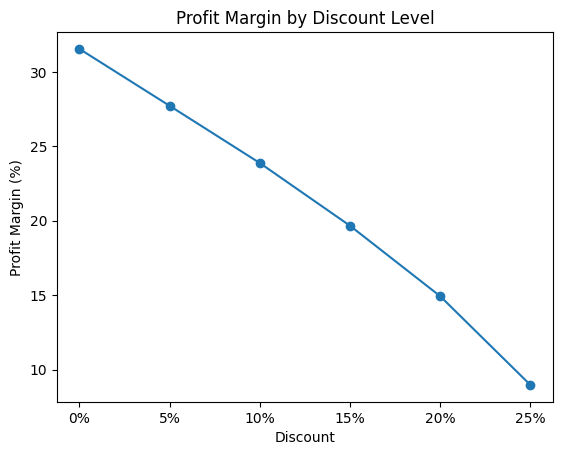

In [55]:
import matplotlib.pyplot as plt

discount_summary["profit_margin"].plot(
    kind="line",
    marker="o",
    title="Profit Margin by Discount Level"
)

plt.xticks(
    discount_summary.index,
    [f"{int(x * 100)}%" for x in discount_summary.index]
)

plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.show()

## 5. Returns & Cancellations

The next objective is to examine order outcomes and identify whether returns or cancellations are concentrated in particular categories or sales channels. Because the dataset does not contain refund amounts, returned and cancelled order values are treated as gross order value rather than realized financial loss.

### Overall Order Outcomes

In [56]:
status_summary = orders.groupby("order_status").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum")
)

status_summary["order_share"] = (
    status_summary["total_orders"]
    / status_summary["total_orders"].sum()
    * 100
)

status_summary["revenue_m"] = (
    status_summary["total_revenue"] / 1_000_000
)

status_summary

,total_orders,total_revenue,order_share,revenue_m
order_status,,,,
Cancelled,890,3.270336e+07,2.966667,32.703363
Completed,27008,9.933521e+08,90.026667,993.352065
Returned,2102,7.596078e+07,7.006667,75.960783


**Interpretation:** 90.0% of orders were completed, while 7.0% were returned and 3.0% were cancelled. Overall, approximately 10.0% of orders did not result in a completed sale. Returned and cancelled orders represent ₹108.7M of gross order value, although the actual financial impact cannot be determined because refund and recovery amounts are not available.

### Order Outcomes by Category

In [57]:
category_status = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
).groupby(
    ["category", "order_status"]
).size().unstack(fill_value=0)

category_status

order_status,Cancelled,Completed,Returned
category,,,
Electronics,220,6846,498
Furniture,256,6813,522
Home Appliances,204,6643,574
Office Supplies,210,6706,508


In [58]:
category_status["total_orders"] = (
    category_status["Cancelled"]
    + category_status["Completed"]
    + category_status["Returned"]
)

category_status["return_rate"] = (
    category_status["Returned"]
    / category_status["total_orders"]
    * 100
)

category_status["cancellation_rate"] = (
    category_status["Cancelled"]
    / category_status["total_orders"]
    * 100
)

category_status[
    ["total_orders", "return_rate", "cancellation_rate"]
]

order_status,total_orders,return_rate,cancellation_rate
category,,,
Electronics,7564,6.583818,2.908514
Furniture,7591,6.876564,3.372415
Home Appliances,7421,7.734807,2.748956
Office Supplies,7424,6.842672,2.828664


**Interpretation:** Return rates are broadly similar across categories, ranging from 6.6% to 7.7%. Home Appliances has the highest return rate at 7.7%, while Electronics has the lowest at 6.6%. Cancellation rates are also relatively consistent, ranging from 2.7% to 3.4%, with Furniture showing the highest rate.

### Order Outcomes by Sales Channel

In [59]:
channel_status = orders.groupby(
    ["sales_channel", "order_status"]
).size().unstack(fill_value=0)

channel_status["total_orders"] = (
    channel_status["Cancelled"]
    + channel_status["Completed"]
    + channel_status["Returned"]
)

channel_status["return_rate"] = (
    channel_status["Returned"]
    / channel_status["total_orders"]
    * 100
)

channel_status["cancellation_rate"] = (
    channel_status["Cancelled"]
    / channel_status["total_orders"]
    * 100
)

channel_status[
    ["total_orders", "return_rate", "cancellation_rate"]
]

order_status,total_orders,return_rate,cancellation_rate
sales_channel,,,
Online,21101,7.009146,2.924032
Store,8899,7.000787,3.067760


**Interpretation:** Return rates are virtually identical across Online and Store orders, at approximately 7.0% for both channels. Cancellation rates are also similar, at 2.9% Online and 3.1% in Store. This suggests that order outcomes are not materially different by sales channel in this dataset.

## 6. Geographic Performance

This section examines revenue and customer distribution across states to identify meaningful geographic differences in business performance.

### Revenue and Customer Distribution by State

In [60]:
state_summary = orders.merge(
    customers[["customer_id", "state"]],
    on="customer_id",
    how="left"
).groupby("state").agg(
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    customers=("customer_id", "nunique")
)

state_summary["revenue_m"] = (
    state_summary["total_revenue"] / 1_000_000
)

state_summary["profit_m"] = (
    state_summary["total_profit"] / 1_000_000
)

state_summary[
    ["customers", "revenue_m", "profit_m"]
].sort_values(
    "revenue_m",
    ascending=False
)

,customers,revenue_m,profit_m
state,,,
Maharashtra,500,215.030546,52.934668
Tamil Nadu,283,125.631677,30.913266
West Bengal,255,119.965621,29.455906
Kerala,253,112.549929,27.782367
Gujarat,250,112.199298,27.722004
Rajasthan,249,108.438868,26.740692
Telangana,251,106.121089,26.173258
Karnataka,233,104.702521,25.673471
Delhi,226,97.376663,23.845003


### Revenue per Customer by State

In [61]:
state_summary["revenue_per_customer"] = (
    state_summary["total_revenue"]
    / state_summary["customers"]
)

state_summary[
    ["customers", "revenue_per_customer"]
].sort_values(
    "revenue_per_customer",
    ascending=False
)

,customers,revenue_per_customer
state,,
West Bengal,255,470453.414353
Karnataka,233,449367.045021
Gujarat,250,448797.191760
Kerala,253,444861.379289
Tamil Nadu,283,443928.187350
Rajasthan,249,435497.462610
Delhi,226,430870.189159
Maharashtra,500,430061.091220
Telangana,251,422793.181594


**Interpretation:** Maharashtra generates the highest total revenue, primarily because it has the largest customer base. Revenue per customer varies across states, ranging from approximately ₹422.8K in Telangana to ₹470.5K in West Bengal. Overall, geographic differences in customer value are moderate, suggesting that market size is a more important driver of total state revenue than large differences in individual customer value.

## 7. Business Recommendations

The analysis identified several areas where the business could improve profitability and operational performance. The recommendations below are based on the observed patterns in revenue, profitability, discounting, and order outcomes.

### 1. Review the economics of low-value Office Supplies products

Office Supplies has a substantially lower profit margin than the other categories, with Writing being the only loss-making subcategory. Six Office Supplies products are loss-making, four of which belong to Writing. The largest losses are concentrated in these four Writing products.

**Recommendation:** Review pricing, bundling, minimum-order thresholds, and fulfillment costs for the loss-making products. Product-level intervention should be targeted rather than applied across the entire Office Supplies category.

### 2. Use deeper discounts selectively

Profitability declines consistently as discount levels increase. Profit margin falls from 31.5% with no discount to 9.0% at a 25% discount, while profit per order declines from approximately ₹12.7K to ₹2.6K.

**Recommendation:** Use deeper discounts selectively and evaluate them against the sales value they generate. Broad discounting should be approached cautiously because the analysis shows a strong association between higher discounts and lower profitability.

### 3. Investigate the higher return rate in Home Appliances

Home Appliances has the highest return rate at 7.7%, compared with 6.6% for Electronics. The difference is moderate, so the analysis does not establish a major category-level return problem, but it identifies Home Appliances as an area worth further investigation.

**Recommendation:** Examine return reasons, individual products, and customer feedback within Home Appliances to determine whether specific products or operational issues are contributing to the higher return rate.

### 4. Prioritize profitable growth over order volume alone

Order volume increased modestly between 2023 and 2025, but overall revenue remained broadly stable and revenue per order declined slightly. Profit margin remained stable at approximately 24.6%.

**Recommendation:** Focus growth initiatives on increasing order value and improving product mix while maintaining profitability, rather than pursuing order volume without considering its impact on revenue per order and margins.